In [1]:
import joblib
import numpy as np
import pandas as pd
from sklearn.svm import SVR
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
# Import dataset
dataset = pd.read_csv(r"C:\Users\Disha\TU Braunschweig\Thesis\Data\Cleaned Dataset.csv")
dataset

,Country,Year,BEV Percentage (Total Number Of Registrations),BEV (New Registrations),GDP,CPI,EG,Recharging Points,AC Recharging Speed (km/h),DC Recharging Speed (km/h),...,Real Range,Purchase price (EUR),Log_BEV Percentage (Total Number Of Registrations),Log_BEV (New Registrations),Log_Recharging Points,Log_GDP,Log_CPI,Log_Available,Log_DC Recharging Speed (km/h),YJ_Purchase price (EUR)
0,Austria,2011,0.18,631.0,308167.0,3.286579,1.6,963,17.500000,175.000000,...,95.000000,30469.93,0.165514,6.448889,6.871091,12.638400,1.455489,1.609438,5.170484,-1.493084
1,Austria,2012,0.13,427.0,316589.4,2.485676,1.0,1063,29.169521,217.394139,...,95.000000,30469.93,0.122218,6.059123,6.969791,12.665364,1.248662,1.609438,5.386301,-1.493084
2,Austria,2013,0.21,656.0,321191.7,2.000156,0.4,1173,48.200000,270.000000,...,142.220000,30469.93,0.190620,6.487684,7.068172,12.679797,1.098664,2.197225,5.602119,-1.493084
3,Austria,2014,0.44,1344.0,330113.5,1.605812,1.0,1393,22.600000,240.000000,...,155.770000,35555.64,0.364643,7.204149,7.239933,12.707195,0.957744,2.639057,5.484797,-0.885657
4,Austria,2015,0.55,1699.0,342083.5,0.896563,0.6,1625,47.700000,381.250000,...,215.220000,42052.00,0.438255,7.438384,7.393878,12.742813,0.640043,3.091042,5.946075,0.277809
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373,Sweden,2020,9.55,27897.0,5012855.0,0.497367,-1.3,47680,39.325301,403.164557,...,286.200000,38311.38,2.356126,10.236310,10.772288,15.427516,0.403708,4.584967,6.001822,-0.451036
374,Sweden,2021,19.09,57454.0,5417760.0,2.163197,1.3,70537,40.904348,493.391304,...,308.730000,40745.01,3.000222,10.958757,11.163907,15.505193,1.151583,5.129899,6.203327,0.003737
375,Sweden,2022,32.84,94603.0,5816415.0,8.369291,3.5,83510,49.314815,594.259259,...,345.440000,43874.27,3.521644,11.457455,11.332734,15.576195,2.237437,5.537334,6.388997,0.697159
376,Sweden,2023,38.42,111338.0,6143187.0,8.548625,1.2,126758,70.307692,649.230769,...,361.794521,45999.05,3.674273,11.620335,11.750043,15.630854,2.256397,5.918894,6.477327,1.244323


In [3]:
# Define the target 
target = 'Log_BEV Percentage (Total Number Of Registrations)'

In [4]:
# Load the PCA tools 
tools = joblib.load("pca_processors.pkl")
scaler = tools['scaler']
pca = tools['pca_model']
features = tools['feature_names']

In [5]:
# Data splitting into Pre and Post COVID
pre_covid_df = dataset[dataset['Year'] < 2020].copy()
post_covid_df = dataset[dataset['Year'] >= 2020].copy()

Please refer the jupyter notebook - **3.1.Feature Selection_BEV Percentage (Primary Target)** to understand the imputation

In [6]:
# Check which columns have NaNs and how many
print("Missing Values Per Column (Pre-COVID)")
print(pre_covid_df[features].isna().sum())

print("\nMissing Values Per Column (Post-COVID)")
print(post_covid_df[features].isna().sum())

Missing Values Per Column (Pre-COVID)
Log_Recharging Points             0
Real Range                        0
Log_Available                     0
YJ_Purchase price (EUR)           0
AC Recharging Speed (km/h)        0
Battery Capacity                  0
Log_DC Recharging Speed (km/h)    0
EG                                0
Log_GDP                           0
Log_CPI                           8
dtype: int64

Missing Values Per Column (Post-COVID)
Log_Recharging Points             0
Real Range                        0
Log_Available                     0
YJ_Purchase price (EUR)           0
AC Recharging Speed (km/h)        0
Battery Capacity                  0
Log_DC Recharging Speed (km/h)    0
EG                                0
Log_GDP                           0
Log_CPI                           1
dtype: int64


In [7]:
# Checking which rows are empty
print("Missing Log_CPI in Pre-COVID")
print(pre_covid_df[pre_covid_df['Log_CPI'].isna()].reset_index()[['Country', 'Year', 'Log_CPI']])
print("\n")
print("Missing Log_CPI in Post-COVID")
print(post_covid_df[post_covid_df['Log_CPI'].isna()].reset_index()[['Country', 'Year', 'Log_CPI']])

Missing Log_CPI in Pre-COVID
    Country  Year  Log_CPI
0  Bulgaria  2014      NaN
1   Croatia  2016      NaN
2    Cyprus  2014      NaN
3    Cyprus  2015      NaN
4    Cyprus  2016      NaN
5    Greece  2014      NaN
6    Greece  2015      NaN
7   Romania  2016      NaN


Missing Log_CPI in Post-COVID
  Country  Year  Log_CPI
0  Greece  2020      NaN


In [8]:
# Imputation for Log_CPI NaNs by filling the spaces with the median

# Calculate the median Log_CPI for every country of Pre-COVID data 
country_medians = pre_covid_df.groupby('Country')['Log_CPI'].median()

# Function to fill the gaps
def impute_by_country(df):
    df_clean = df.copy()
    
    # Loop through the data, if Log_CPI is missing, we look up that specific country's median from our 'country_medians' list.
    df_clean['Log_CPI'] = df_clean['Log_CPI'].fillna(df_clean['Country'].map(country_medians))
    
    return df_clean

# Apply the fix to both datasets 
pre_covid_fixed = impute_by_country(pre_covid_df)
post_covid_fixed = impute_by_country(post_covid_df)

# Extract 10 features
X_train_imputed = pre_covid_fixed[features]
X_test_imputed = post_covid_fixed[features]

In [9]:
# Scale the features using the scaler loaded from the .pkl file
X_train_scaled = scaler.transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [10]:
# Transform the features into 3 Principal Components using the loaded PCA model 
# and convert them back to a dataframe for easy handling
X_train_pca = pd.DataFrame(
    pca.transform(X_train_scaled), 
    columns=['PC1', 'PC2', 'PC3'], 
    index=pre_covid_fixed.index
)

X_test_pca = pd.DataFrame(
    pca.transform(X_test_scaled), 
    columns=['PC1', 'PC2', 'PC3'], 
    index=post_covid_fixed.index
)

In [11]:
# Define the targets 
y_train = pre_covid_fixed[target]
y_test = post_covid_fixed[target]

print(f"Train Shape (PCs): {X_train_pca.shape}")
print(f"Test Shape (PCs): {X_test_pca.shape}")

Train Shape (PCs): (243, 3)
Test Shape (PCs): (135, 3)


In [12]:
# Validation split of the Pre-COVID data
X_train_inner, X_val_inner, y_train_inner, y_val_inner = train_test_split(
    X_train_pca, y_train, test_size=0.2, random_state=42
)

**1. Multi-Linear Regresssion**

In [13]:
# Initialize Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_inner, y_train_inner)

# Predict on Train set
y_pred_train = lr_model.predict(X_train_inner)

# Predict on Validation set
y_pred_val = lr_model.predict(X_val_inner)

# Print Results
print(f"Train R2 Score: {r2_score(y_train_inner, y_pred_train):.4f}")
print(f"Train MAE: {mean_absolute_error(y_train_inner, y_pred_train):.4f}")
print()
print(f"Validation R2 Score: {r2_score(y_val_inner, y_pred_val):.4f}")
print(f"Validation MAE: {mean_absolute_error(y_val_inner, y_pred_val):.4f}")
print()
print(f"Model Coefficients (PCs): {lr_model.coef_}")
print(f"Model Intercept: {lr_model.intercept_:.4f}")

Train R2 Score: 0.3595
Train MAE: 0.2074

Validation R2 Score: 0.2531
Validation MAE: 0.2127

Model Coefficients (PCs): [-0.07847845 -0.09233944 -0.10076999]
Model Intercept: 0.3188


In [14]:
# Predict on Train set
y_pred_train = lr_model.predict(X_train_inner) 

# Test on Test data
y_pred_post = lr_model.predict(X_test_pca)

# Print Results
# Print Results
print(f"Train R2 Score (Pre-COVID): {r2_score(y_train_inner, y_pred_train):.4f}")
print(f"Train MAE: {mean_absolute_error(y_train_inner, y_pred_train):.4f}")
print()
print(f"Test R2 Score: {r2_score(y_test, y_pred_post):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_post):.4f}")

Train R2 Score (Pre-COVID): 0.3595
Train MAE: 0.2074

Test R2 Score: -1.7652
Test MAE: 1.1820


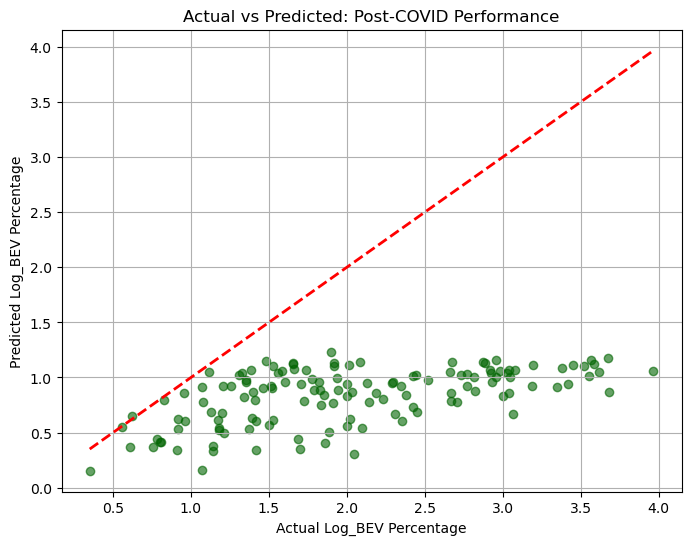

In [15]:
# Visualization 
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_post, alpha=0.6, color='darkgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Log_BEV Percentage")
plt.ylabel("Predicted Log_BEV Percentage")
plt.title("Actual vs Predicted: Post-COVID Performance")
plt.grid(True)
plt.show()

**2. Support Vector Machine**

In [16]:
# Initialize the SVM Regressor
svm_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svm_model.fit(X_train_inner, y_train_inner)

SVR()

In [17]:
# Predict on Train set
y_pred_train = svm_model.predict(X_train_inner)

# Predict on Validation set
y_pred_val = svm_model.predict(X_val_inner)

# Print Results
print(f"Train R2 Score: {r2_score(y_train_inner, y_pred_train):.4f}")
print(f"Train MAE: {mean_absolute_error(y_train_inner, y_pred_train):.4f}")
print()
print(f"Validation R2 Score: {r2_score(y_val_inner, y_pred_val):.4f}")
print(f"Validation MAE: {mean_absolute_error(y_val_inner, y_pred_val):.4f}")

Train R2 Score: 0.5621
Train MAE: 0.1657

Validation R2 Score: 0.3818
Validation MAE: 0.1723


In [18]:
# Predict on Train set
y_pred_train = svm_model.predict(X_train_inner) 

# Test on Test data
y_pred_post = svm_model.predict(X_test_pca)

# Print Results
print(f"Train R2 Score (Pre-COVID): {r2_score(y_train_inner, y_pred_train):.4f}")
print(f"Train MAE: {mean_absolute_error(y_train_inner, y_pred_train):.4f}")
print()
print(f"Test R2 Score: {r2_score(y_test, y_pred_post):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_post):.4f}")

Train R2 Score (Pre-COVID): 0.5621
Train MAE: 0.1657

Test R2 Score: -2.2491
Test MAE: 1.2702


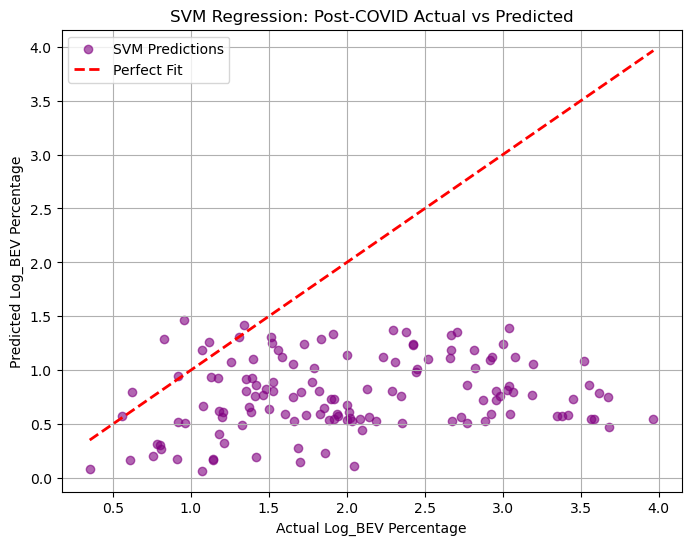

In [19]:
# Visualization for SVM Post-COVID 
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_post, alpha=0.6, color='purple', label='SVM Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel("Actual Log_BEV Percentage")
plt.ylabel("Predicted Log_BEV Percentage")
plt.title("SVM Regression: Post-COVID Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()